In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from scipy.optimize import minimize, linprog
import sys
# from utils_3 import leaderboard_dist

## 1. Define Voter Utility Distributions
Create functions to sample `m` candidates and `n` voters using different distributions, specifically implementing independent standard normal distributions and beta distributions.

In [4]:

def sample_utilities_0_1(n_voters, m_candidates, seed=None):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 1, size=(n_voters, m_candidates))

def sample_utilities_normal(n_voters, m_candidates, seed=None):
    rng = np.random.default_rng(seed)
    return rng.standard_normal((n_voters, m_candidates))

def sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=None):
    rng = np.random.default_rng(seed)
    return rng.beta(a, b, size=(n_voters, m_candidates))

## 2. Implement Sampling Distribution Classes
Define a configurable class to represent the sampling distribution $\mu(\{x,y\} | x)$, allowing switching between independent uniform sampling and correlated sampling distributions.

In [ ]:
class SamplingDistribution:
    def __init__(self, n_candidates, method="uniform", utilities=None, beta=1.0, voter_dist=None, **kwargs):
        self.M = n_candidates
        self.method = method
        self.utilities = utilities
        self.beta = beta
        self.voter_dist = voter_dist
        self.kwargs = kwargs
        
        if self.method == "borda_correlated":
            self._compute_borda_probs()
            
    def _compute_borda_probs(self):
        # TODO: work in progress
        # We need utilities and beta to compute the BT win rates
        if self.utilities is None:
            raise ValueError("utilities must be provided for borda_correlated")
            
        V, C = self.utilities.shape
        vd = self.voter_dist if self.voter_dist is not None else np.ones(V, dtype=float) / V
        
        P_inf = np.zeros((C, C), dtype=float)
        for v, u in enumerate(self.utilities):
            diffs = u[:, None] - u[None, :]
            P_inf += vd[v] * expit(self.beta * diffs)
        np.fill_diagonal(P_inf, 0.5)
        
        S = self.kwargs.get("S", 1000)
        T = self.kwargs.get("T", 10)
        
        probs = np.ones(self.M) / self.M
        wins = np.zeros(self.M)
        
        for t in range(1, T + 1):
            xs = np.random.choice(self.M, size=S, p=probs)
            ys = np.random.choice(self.M, size=S, p=probs)
            
            valid = xs != ys
            xs = xs[valid]
            ys = ys[valid]
            
            if len(xs) > 0:
                p_win = P_inf[xs, ys]
                won = np.random.binomial(1, p_win)
                
                # Fast accumulation via bincount
                wins_x = np.bincount(xs[won == 1], minlength=self.M)
                wins_y = np.bincount(ys[won == 0], minlength=self.M)
                wins += wins_x + wins_y
                
            # Construct leaderboard (pi)
            order = np.argsort(-wins)
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, self.M + 1)
            
            # probs proportional to probs_t * 1 / (pi)^t
            probs = probs * (1.0 / (ranks ** t))
            if probs.sum() > 0:
                probs = probs / probs.sum()
            else:
                probs = np.ones(self.M) / self.M
                
        self.borda_probs = probs
        
    def get_conditional_probs(self, x, remaining_candidates=None):
        """
        Returns mu({x,y} | x) for all y in remaining_candidates.
        If remaining_candidates is None, assumes all candidates.
        """
        if remaining_candidates is None:
            remaining_candidates = np.arange(self.M)
            
        rem_list = list(remaining_candidates)
        if x not in rem_list:
            raise ValueError(f"Candidate {x} not in remaining candidates.")
            
        R = len(remaining_candidates)
        probs = np.zeros(self.M)
        
        if R <= 1:
            return probs
            
        if self.method == "uniform":
            # Uniform over all y != x
            val = 1.0 / (R - 1)
            for y in remaining_candidates:
                if y != x:
                    probs[y] = val
        
        elif self.method == "beta":
            # Use Beta PDF values on a regular grid, then normalize
            alpha = self.kwargs.get("alpha", 1.0)
            beta_param = self.kwargs.get("beta", 1.0)

            grid = np.linspace(0.0, 1.0, self.M + 2)[1:-1]
            weights = np.zeros(self.M)

            for y in remaining_candidates:
                if y != x:
                    t = grid[y]
                    weights[y] = (t ** (alpha - 1.0)) * ((1.0 - t) ** (beta_param - 1.0))

            total = weights.sum()
            if total > 0:
                probs = weights / total
            
        elif self.method == "basic_correlated":
            # E.g. candidates with closer index are more likely to be compared
            weights = np.zeros(self.M)
            for y in remaining_candidates:
                if y != x:
                    dist = abs(x - y)
                    weights[y] = 1.0 / (dist + 1.0)
            probs = weights / weights.sum()
            
        elif self.method == "borda_correlated":
            # TODO: work in progress
            # the marginal probability of y given x is just proportional to borda_probs[y]
            for y in remaining_candidates:
                if y != x:
                    probs[y] = self.borda_probs[y]
            if probs.sum() > 0:
                probs /= probs.sum()
            
        else:
            raise NotImplementedError(f"Method {self.method} not implemented.")
            
        return probs

## 4. Calculate Population Win-Rate Matrix
Compute the pairwise win-probabilities $p(x > y)$ using the Bradley-Terry model in the infinite-sample limit by averaging the sigmoid of utility differences over all voters.

In [5]:
def compute_win_rate_matrix(utilities, voter_dist=None, beta=1.0):
    """
    Computes P[i,j] = p(i > j)
    """
    V, C = utilities.shape
    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
        
    P = np.zeros((C, C), dtype=float)
    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)
    np.fill_diagonal(P, 0.5)
    return P

## 5. Implement Modified Borda Count
Write a function to compute the modified Borda count for each candidate using the formula $BC(x) = \sum_{y}(\mu(\{x,y\} | x) p(x > y))$.

In [6]:
def modified_borda(P, sampling_dist, remaining=None):
    """
    Computes BC(x) = sum_y mu({x,y}|x) P(x > y)
    """
    R = P.shape[0]
    if remaining is None:
        remaining = list(range(R))
        
    scores = np.zeros(R)
    for x in remaining:
        probs_y = sampling_dist.get_conditional_probs(x, remaining)
        # sum only over y in remaining
        bc_x = 0.0
        for y in remaining:
            if y != x:
                bc_x += probs_y[y] * P[x, y]
        scores[x] = bc_x
        
    return scores

def borda_ranking(P, sampling_dist):
    scores = modified_borda(P, sampling_dist)
    return np.argsort(-scores)

## 6. Implement Borda with Peeling
Implement a peeling mechanism that iteratively calculates $BC(x)$ on the remaining candidates, selects the candidate with the highest score, and removes them from the candidate pool to form a ranking.

In [7]:
def borda_peeling(P, sampling_dist):
    """
    Computes a ranking by iteratively computing Borda scores on remaining pool
    and popping the highest scoring candidate.
    """
    R = P.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        # compute borda scores restricted to remaining
        # get_conditional_probs will be aware of remaining candidates
        scores = np.zeros(R)
        for x in remaining:
            probs = sampling_dist.get_conditional_probs(x, remaining)
            bc_x = sum([probs[y] * P[x, y] for y in remaining if y != x])
            scores[x] = bc_x
            
        # among remaining, find argmax
        local_scores = [scores[x] for x in remaining]
        best_idx_local = np.argmax(local_scores)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

In [8]:
def sample_win_rate_matrix(P, n_samples):
    """
    Given an exact win-rate matrix P, sample a finite number of pairwise comparisons
    and return an empirical win-rate matrix.
    """
    C = P.shape[0]
    emp_P = np.zeros((C, C), dtype=float)
    if n_samples is None or n_samples == np.inf:
        return P
        
    pairs = [(i, j) for i in range(C) for j in range(i + 1, C)]
    # Distribute samples evenly across all pairs for simplicity, 
    # or just sample randomly based on P. Here we do binomial sampling for each pair.
    samples_per_pair = n_samples // len(pairs)
    if samples_per_pair == 0:
        samples_per_pair = 1
        
    for i, j in pairs:
        wins_i = np.random.binomial(samples_per_pair, P[i, j])
        win_rate_i = wins_i / samples_per_pair
        emp_P[i, j] = win_rate_i
        emp_P[j, i] = 1.0 - win_rate_i
        
    np.fill_diagonal(emp_P, 0.5)
    return emp_P

def copeland_ranking(P, sampling_dist, tie_tol=1e-12):
    R = P.shape[0]
    scores = np.zeros(R)
    for x in range(R):
        probs_y = sampling_dist.get_conditional_probs(x, range(R))
        bc_x = 0.0
        for y in range(R):
            if y != x:
                if P[x, y] > 0.5 + tie_tol:
                    bc_x += probs_y[y] * 1.0
                elif P[x, y] < 0.5 - tie_tol:
                    bc_x += probs_y[y] * -1.0
        scores[x] = bc_x
    return np.argsort(-scores)

def copeland_peeling(P, sampling_dist, tie_tol=1e-12):
    R = P.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        scores = np.zeros(R)
        for x in remaining:
            probs = sampling_dist.get_conditional_probs(x, remaining)
            bc_x = 0.0
            for y in remaining:
                if y != x:
                    if P[x, y] > 0.5 + tie_tol:
                        bc_x += probs[y] * 1.0
                    elif P[x, y] < 0.5 - tie_tol:
                        bc_x += probs[y] * -1.0
            scores[x] = bc_x
            
        local_scores = [scores[x] for x in remaining]
        best_idx_local = np.argmax(local_scores)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

def maximal_lottery_probs(P, sampling_dist, remaining):
    R = len(remaining)
    if R == 1:
        return np.array([1.0])

    margins = np.zeros((R, R))
    for r_i, i in enumerate(remaining):
        pi = sampling_dist.get_conditional_probs(i, remaining)
        for r_j, j in enumerate(remaining):
            if i != j:
                pj = sampling_dist.get_conditional_probs(j, remaining)
                margins[r_i, r_j] = pi[j] * P[i, j] - pj[i] * P[j, i]
                # margins[r_i, r_j] = P[i, j] - P[j, i]
                
    # Solve minimax:
    # max v s.t. M^T x >= v
    # => min -v s.t. -M^T x + v <= 0
    # Add v as the last variable
    c = np.zeros(R + 1, dtype=float)
    c[-1] = -1.0 # Minimize -v

    A_ub = np.hstack((-margins.T, np.ones((R, 1), dtype=float)))
    b_ub = np.zeros(R, dtype=float)

    A_eq = np.zeros((1, R + 1), dtype=float)
    A_eq[0, :R] = 1.0
    b_eq = np.array([1.0])

    bounds = [(0.0, 1.0)] * R + [(None, None)] # v is unbounded

    result = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        print("Warning: LP failed to find a solution, returning uniform distribution.")
        print("LP message:", result.message)
        return np.ones(R, dtype=float) / R
        
    return np.asarray(result.x[:R], dtype=float)

def maximal_lottery_ranking(P, sampling_dist, tie_tol=1e-12):
    R = P.shape[0]
    lottery = maximal_lottery_probs(P, sampling_dist, list(range(R)))
    return np.argsort(-lottery)

def maximal_lottery_peeling_max(P, sampling_dist):
    R = P.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        lottery = maximal_lottery_probs(P, sampling_dist, remaining)
        best_idx_local = np.argmax(lottery)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

def maximal_lottery_peeling_sample(P, sampling_dist):
    R = P.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        lottery = maximal_lottery_probs(P, sampling_dist, remaining)
        lottery = np.maximum(lottery, 0)
        s = np.sum(lottery)
        if s > 0:
            lottery /= s
        else:
            lottery = np.ones(len(remaining)) / len(remaining)
            
        best_idx_local = np.random.choice(len(remaining), p=lottery)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

## 7. Compute Supremum Leaderboard Distortion

In [9]:
def compute_supremum_leaderboard_distortion(ranking, true_ranking, avg_utils):
    """
    Computes supremum of leaderboard distortion over all monotonically decreasing weights.
    By identifying extreme points, this boils down to max prefix sum ratio.
    """
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)
    
    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]
    
    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)
    
    ratio = np.max(num_cumsum / denom_cumsum)
    
    return ratio

## 8. Run Simulations and Visualize Results
Set up a simulation loop calculating the true average utility rankings, generated Borda rankings, and their respective distortions across multiple values of $\beta$ and distribution parameters, then plot the resulting distortion arrays.

Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


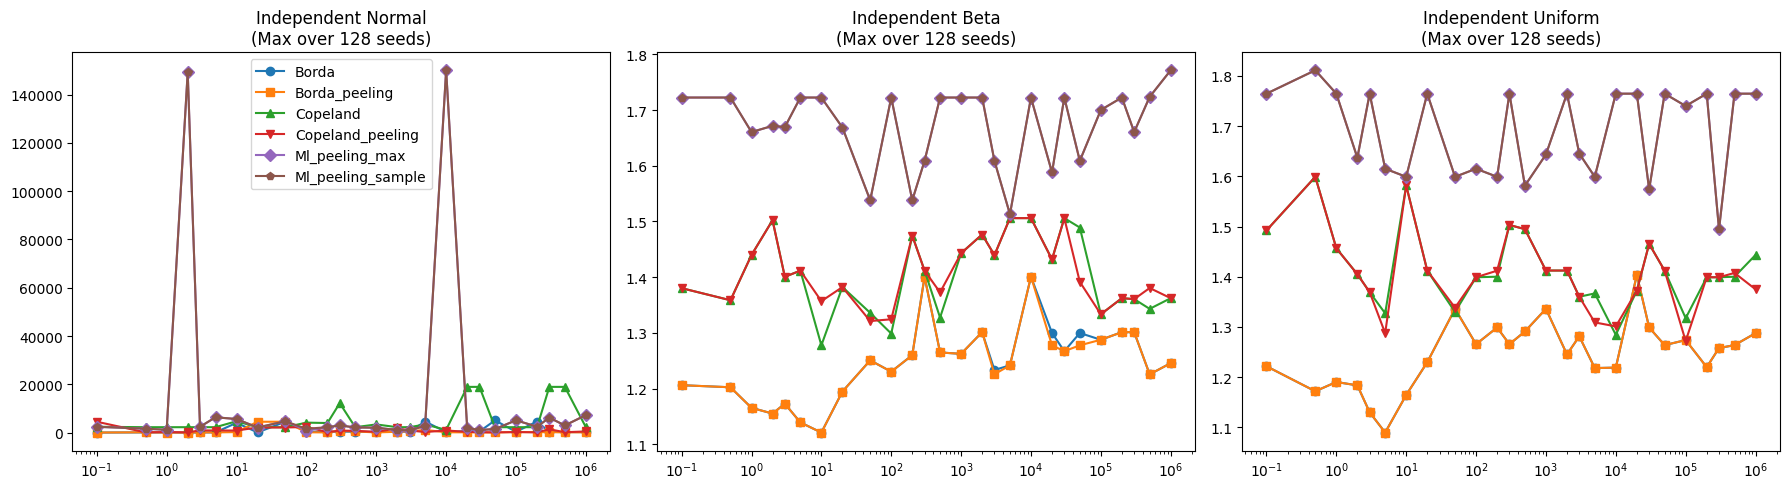

In [ ]:
import concurrent.futures
from collections import defaultdict

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]

n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes

methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample']

def run_sim(utilities, method, n_samples=None):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    sampling_dist = SamplingDistribution(m_candidates, method=method, kwargs={"alpha": 2.0, "beta": 5.0})
    
    for b in betas:
        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P, sampling_dist)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P, sampling_dist)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P, sampling_dist)
            ml_dist_pmax = compute_supremum_leaderboard_distortion(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
        out['ml_peeling_max'].append(ml_dist_pmax)

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P, sampling_dist)
            ml_dist_psamp = compute_supremum_leaderboard_distortion(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
        out['ml_peeling_sample'].append(ml_dist_psamp)

        out['borda'].append(compute_supremum_leaderboard_distortion(borda_rank, true_rank, avg_utils))
        out['borda_peeling'].append(compute_supremum_leaderboard_distortion(peel_rank, true_rank, avg_utils))
        out['copeland'].append(compute_supremum_leaderboard_distortion(cope_rank, true_rank, avg_utils))
        out['copeland_peeling'].append(compute_supremum_leaderboard_distortion(cope_peel, true_rank, avg_utils))
        
        # rand_rank = np.random.permutation(m_candidates)
        # out['random'].append(compute_supremum_leaderboard_distortion(rand_rank, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    # out_ind_norm = run_sim(dist_normal, "uniform", n_samples_finite)
    # out_ind_beta = run_sim(dist_beta, "uniform", n_samples_finite)
    # out_ind_unif = run_sim(dist_unif, "uniform", n_samples_finite)
    out_ind_norm = run_sim(dist_normal, "beta", n_samples_finite)
    out_ind_beta = run_sim(dist_beta, "beta", n_samples_finite)
    out_ind_unif = run_sim(dist_unif, "beta", n_samples_finite)
    
    return {
        "independent_normal": out_ind_norm,
        # "correlated_normal": out_cor_norm,
        "independent_beta": out_ind_beta,
        "independent_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        # for dist in ["independent_normal", "correlated_normal", "independent_beta", "independent_uniform"]
        for dist in ["independent_normal", "independent_beta", "independent_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    for dist in all_runs:
        for m in methods_to_run:
            results[f"{dist}_{m}"] = np.nanmax(all_runs[dist][m], axis=0)
            
    return results

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # labels = ['borda', 'peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample', 'random']
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x']

    dist_names = ["independent_normal", "independent_beta", "independent_uniform"]
    titles = ["Independent Normal", "Independent Beta", "Independent Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            print(d_name, m)
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results = aggregate_results(seed_results)
plot_results(results)

# 9. Correlated Beta - simple

Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


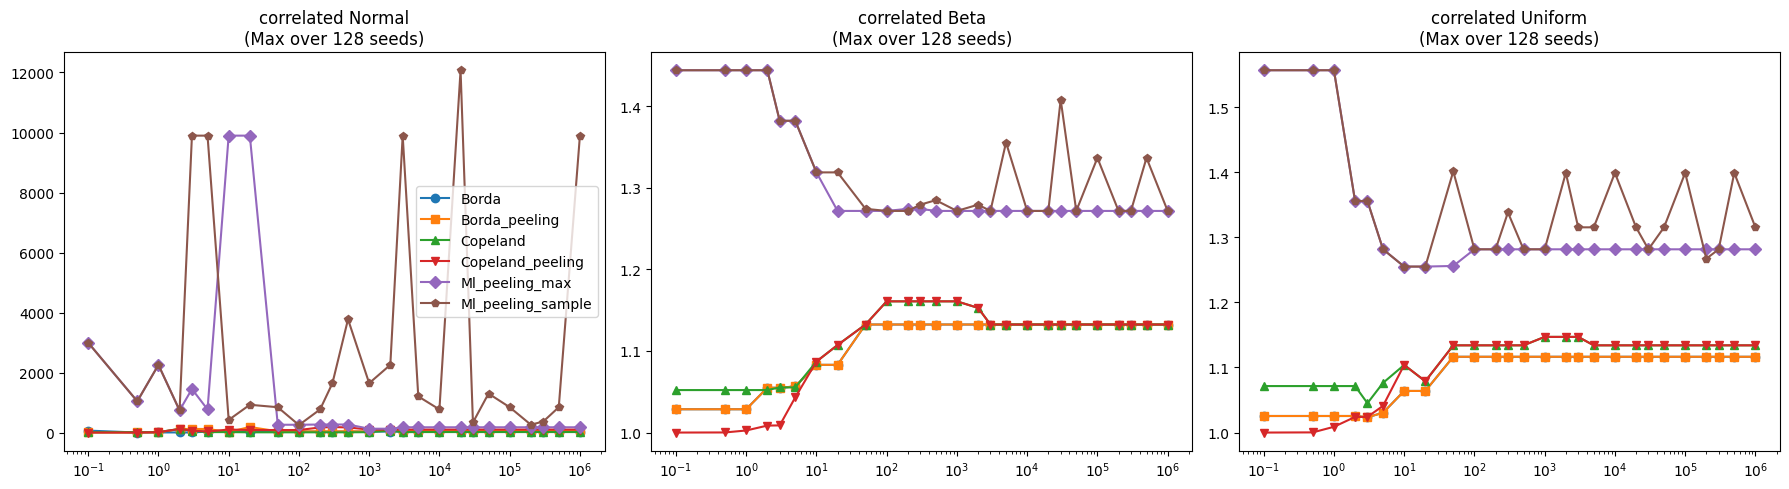

In [12]:
import concurrent.futures
from collections import defaultdict

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]

n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes

methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample']

def run_sim(utilities, method, n_samples=None, beta=1.0):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    for b in betas:
        # Pass utilities and current beta so borda_correlated can compute its BT logic iteratively
        sampling_dist = SamplingDistribution(m_candidates, method=method, utilities=utilities, beta=b, voter_dist=voter_dist, S=1000, T=10, alpha=2.0, beta_param=5.0)

        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P, sampling_dist)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P, sampling_dist)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P, sampling_dist)
            ml_dist_pmax = compute_supremum_leaderboard_distortion(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
        out['ml_peeling_max'].append(ml_dist_pmax)

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P, sampling_dist)
            ml_dist_psamp = compute_supremum_leaderboard_distortion(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
        out['ml_peeling_sample'].append(ml_dist_psamp)

        out['borda'].append(compute_supremum_leaderboard_distortion(borda_rank, true_rank, avg_utils))
        out['borda_peeling'].append(compute_supremum_leaderboard_distortion(peel_rank, true_rank, avg_utils))
        out['copeland'].append(compute_supremum_leaderboard_distortion(cope_rank, true_rank, avg_utils))
        out['copeland_peeling'].append(compute_supremum_leaderboard_distortion(cope_peel, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    # We can invoke varying methods (like borda_correlated) here by replacing the method argument:
    current_method = "basic_correlated"
    
    out_ind_norm = run_sim(dist_normal, current_method, n_samples_finite)
    out_ind_beta = run_sim(dist_beta, current_method, n_samples_finite)
    out_ind_unif = run_sim(dist_unif, current_method, n_samples_finite)
    
    return {
        "correlated_normal": out_ind_norm,
        "correlated_beta": out_ind_beta,
        "correlated_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        for dist in ["correlated_normal", "correlated_beta", "correlated_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    for dist in all_runs:
        for m in methods_to_run:
            results[f"{dist}_{m}"] = np.nanmax(all_runs[dist][m], axis=0)
            
    return results

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x']

    dist_names = ["correlated_normal", "correlated_beta", "correlated_uniform"]
    titles = ["correlated Normal", "correlated Beta", "correlated Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results = aggregate_results(seed_results)
plot_results(results)

# 10. Correlated Beta - WIP

Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


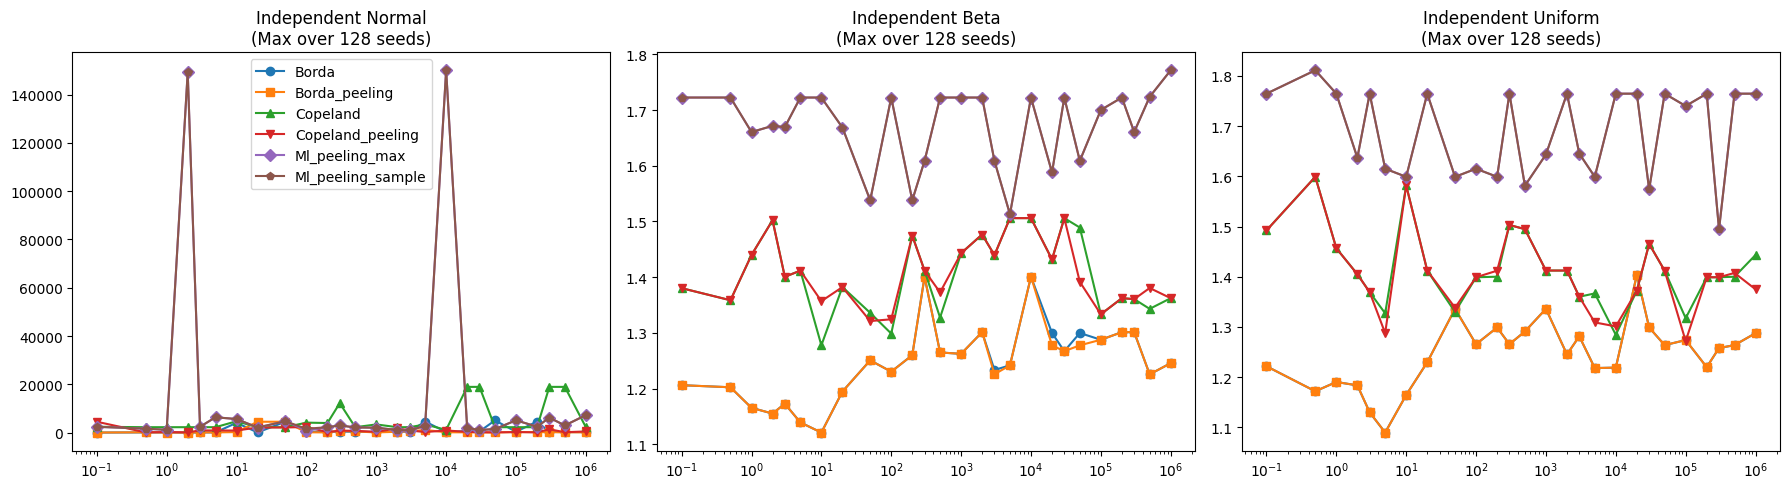

In [ ]:
import concurrent.futures
from collections import defaultdict

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]

n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes

methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample']

def run_sim(utilities, method, n_samples=None, beta=1.0):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    for b in betas:
        # Pass utilities and current beta so borda_correlated can compute its BT logic iteratively
        sampling_dist = SamplingDistribution(m_candidates, method=method, utilities=utilities, beta=b, voter_dist=voter_dist, S=1000, T=10, alpha=2.0, beta_param=5.0)

        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P, sampling_dist)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P, sampling_dist)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P, sampling_dist)
            ml_dist_pmax = compute_supremum_leaderboard_distortion(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
        out['ml_peeling_max'].append(ml_dist_pmax)

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P, sampling_dist)
            ml_dist_psamp = compute_supremum_leaderboard_distortion(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
        out['ml_peeling_sample'].append(ml_dist_psamp)

        out['borda'].append(compute_supremum_leaderboard_distortion(borda_rank, true_rank, avg_utils))
        out['borda_peeling'].append(compute_supremum_leaderboard_distortion(peel_rank, true_rank, avg_utils))
        out['copeland'].append(compute_supremum_leaderboard_distortion(cope_rank, true_rank, avg_utils))
        out['copeland_peeling'].append(compute_supremum_leaderboard_distortion(cope_peel, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    # We can invoke varying methods (like borda_correlated) here by replacing the method argument:
    current_method = "borda_correlated"
    
    out_ind_norm = run_sim(dist_normal, current_method, n_samples_finite)
    out_ind_beta = run_sim(dist_beta, current_method, n_samples_finite)
    out_ind_unif = run_sim(dist_unif, current_method, n_samples_finite)
    
    return {
        "correlated_normal": out_ind_norm,
        "correlated_beta": out_ind_beta,
        "correlated_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        for dist in ["correlated_normal", "correlated_beta", "correlated_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    for dist in all_runs:
        for m in methods_to_run:
            results[f"{dist}_{m}"] = np.nanmax(all_runs[dist][m], axis=0)
            
    return results

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x']

    dist_names = ["correlated_normal", "correlated_beta", "correlated_uniform"]
    titles = ["correlated Normal", "correlated Beta", "correlated Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results = aggregate_results(seed_results)
plot_results(results)